# Bibliotecas e dados

In [2]:
import pandas as pd
import re
import numpy as np
from io import StringIO   # <-- use isto
import matplotlib.pyplot as plt
import mplcursors
#%matplotlib widget

In [4]:
hs = pd.read_csv("Oct_Contri_hs.csv")
ls = pd.read_csv("Oct_Contri_ls.csv")

In [6]:
hs

,index,valor,array
0,6,14.636383,0.099285
1,7,17.702530,0.200384
2,8,27.727668,0.121939
3,9,42.281496,0.105971
4,10,44.715964,0.048656
...,...,...,...
148,154,3226.105227,0.000005
149,155,3231.030889,0.000005
150,156,3231.074672,0.000005
151,157,3236.905072,0.000002


In [8]:
ls

,index,valor,array,modos
0,6,16.800836,0.069548,16.800836
1,7,24.615750,0.172795,24.615750
2,8,38.347452,0.116668,38.347452
3,9,49.869031,0.027723,49.869031
4,10,50.774919,0.017137,50.774919
...,...,...,...,...
148,154,3229.938790,0.000004,3229.938790
149,155,3233.978123,0.000009,3233.978123
150,156,3234.192034,0.000009,3234.192034
151,157,3238.249430,0.000002,3238.249430


In [10]:
def renomear_index_por_atom(df, lista_atomica):
    """
    df: DataFrame final já criado (159 linhas)
    lista_atomica: lista de strings com linhas contendo símbolo, massa e coordenadas
    """
    # Extrair apenas o símbolo atômico de cada linha
    simbolos = [linha.split()[0] for linha in lista_atomica]

    novo_index = []
    contadores = {}  # exemplo: {"C":1, "H":1, "O":1}

    for simbolo in simbolos:
        if simbolo not in contadores:
            contadores[simbolo] = 1

        nome = f"{simbolo}{contadores[simbolo]}"

        # Cada átomo corresponde a 3 linhas do DataFrame
        novo_index.extend([nome, nome, nome])

        contadores[simbolo] += 1

    # Aplicar ao DataFrame
    df.index = novo_index
    return df

In [12]:
lista_atomica = [
    "C     12.01100     -5.520264845720    -1.115707479413     0.897605357711",
    "C     12.01100      5.520452518574    -1.115723577676    -0.897303843581",
    "C     12.01100     -4.717428065189    -2.832744402920    -1.052293345657",
    "C     12.01100      4.717889260456    -2.832871384362     1.052539744557",
    "C     12.01100     -6.606891583710    -4.394353536396    -2.145371212533",
    "C     12.01100      6.607390344081    -4.394770037602     2.145057663476",
    "H      1.00800     -6.034676638152    -5.702671048362    -3.610513207819",
    "H      1.00800      6.035355292474    -5.703243699406     3.610128208214",
    "C     12.01100     -9.066360064720    -4.254075940367    -1.367474199670",
    "C     12.01100      9.066728222324    -4.254628795559     1.366661179528",
    "H      1.00800    -10.511265866955    -5.441454535473    -2.193507432040",
    "H      1.00800     10.511683451023    -5.442288278089     2.192214608511",
    "C     12.01100     -9.770578178244    -2.550150813499     0.537008619724",
    "C     12.01100      9.770715542304    -2.550563288206    -0.537744580628",
    "C     12.01100     -8.020310169408    -0.994075397066     1.671451991949",
    "C     12.01100      8.020340638195    -0.994159763824    -1.671623622263",
    "N     14.00700    -12.378556223629    -2.409089787803     1.327755332438",
    "N     14.00700     12.378519201596    -2.409668247301    -1.329083667815",
    "O     15.99900     -2.416219571234    -2.903288706253    -1.747879105684",
    "O     15.99900      2.416744722791    -2.903297471670     1.748496268000",
    "O     15.99900    -13.888079551984    -3.808782207744     0.304531482779",
    "O     15.99900     13.888086558489    -3.809858819272    -0.306655649681",
    "O     15.99900    -12.928247729108    -0.893379703175     2.972383430461",
    "O     15.99900     12.927953998234    -0.893763939771    -2.973651371779",
    "N     14.00700     -3.564693824940     0.330596326795     1.821477061978",
    "N     14.00700      3.564735878326     0.330650146953    -1.820781402117",
    "H      1.00800     -8.649557134583     0.282766099379     3.140249066382",
    "H      1.00800      8.649412269810     0.282821974285    -3.140385031032",
    "C     12.01100     -3.655291153411     2.031063880783     3.536851991090",
    "C     12.01100      3.655056986834     2.030838091497    -3.536441828175",
    "H      1.00800     -5.377071945919     2.549964151628     4.541848489297",
    "C     12.01100     -1.310384408628     3.291486455883     4.191970491532",
    "C     12.01100      1.310046939264     3.291108840358    -4.191443794614",
    "H      1.00800      5.376641385352     2.549464552762    -4.541919460723",
    "N     14.00700      0.741387328905     2.577206192449     2.876254138590",
    "C     12.01100     -1.181804924987     5.094014086095     6.099820375343",
    "C     12.01100      1.181227147302     5.093277810341    -6.099625154786",
    "N     14.00700     -0.741599888669     2.576856952799    -2.875508194828",
    "C     12.01100      2.955085757498     3.593295877611     3.458276208785",
    "H      1.00800     -2.881312278661     5.626521498741     7.109401298976",
    "C     12.01100      1.133402062841     6.155165171408     6.683444521954",
    "H      1.00800      2.880649251831     5.625718623776    -7.109394845466",
    "C     12.01100     -1.134093225637     6.154099585433    -6.683384268274",
    "C     12.01100     -2.955402360777     3.592657946625    -3.457669967266",
    "H      1.00800      4.565823766006     2.942241245285     2.371070162337",
    "C     12.01100      3.249950073085     5.383762691732     5.348576630598",
    "H      1.00800      1.287843102082     7.556621529536     8.167726618197",
    "C     12.01100     -3.250503942796     5.382767012137    -5.348272220948",
    "H      1.00800     -1.288716667155     7.555250245205    -8.167932773460",
    "H      1.00800     -4.566072050899     2.941572288416    -2.370400223201",
    "H      1.00800      5.104212185344     6.145690387923     5.751937690401",
    "H      1.00800     -5.104864181243     6.144415297879    -5.751727712650",
    "Fe    55.85000      0.000239285754    -0.441112578978     0.000655619575"
]

In [14]:
arquivo = "ls/v2/vib_mode.txt"

with open(arquivo, "r") as f:
    linhas = f.readlines()

# --------------------
# 1) Parte inicial (159 linhas)
# --------------------

linhas_159 = linhas[:159]

header = re.split(r"\s+", linhas[0].strip())
header = [h for h in header if h != ""]

df = pd.read_csv(
    StringIO("".join(linhas_159)),
    delim_whitespace=True,
    names=header,
    skiprows=1
)

# --------------------
# 2) Blocos seguintes
# --------------------

blocos = []
i = 159

num_regex = r"^\s*\d+(\s+\d+)*\s*$"

while i < len(linhas):

    # Linha com números das colunas
    col_header_line = linhas[i].strip()
    novas_cols = re.split(r"\s+", col_header_line)
    novas_cols = [c for c in novas_cols if c != ""]
    i += 1

    bloco_linhas = []

    # Acumular linhas do bloco
    while i < len(linhas) and not re.match(num_regex, linhas[i]):
        bloco_linhas.append(linhas[i])
        i += 1

    # Se não houver linhas, pula
    if len(bloco_linhas) == 0:
        continue

    # ----------------------------
    # Detectar número real de colunas no bloco
    # ----------------------------
    primeira_linha = bloco_linhas[0].strip()
    ncols = len(re.split(r"\s+", primeira_linha))

    # criar nomes para todas as colunas
    # primeira é índice, outras são novas_cols (até onde existirem)
    nomes = ["idx"] + novas_cols + [f"extra_{k}" for k in range(len(novas_cols)+1, ncols)]

    df_bloco = pd.read_csv(
        StringIO("".join(bloco_linhas)),
        delim_whitespace=True,
        names=nomes
    )

    df_bloco = df_bloco.drop(columns=["idx"])
    blocos.append(df_bloco)

# --------------------
# 3) Concatenar
# --------------------

for b in blocos:
    df = pd.concat([df, b], axis=1)

C:\Users\55219\AppData\Local\Temp\ipykernel_26464\2881512804.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\2881512804.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\2881512804.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\2881512804.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\2881512804.p

In [16]:
df = renomear_index_por_atom(df, lista_atomica)
normal_modes_ls = df

In [18]:
arquivo = "hs/vib_mode.txt"

with open(arquivo, "r") as f:
    linhas = f.readlines()

# --------------------
# 1) Parte inicial (159 linhas)
# --------------------

linhas_159 = linhas[:159]

header = re.split(r"\s+", linhas[0].strip())
header = [h for h in header if h != ""]

df = pd.read_csv(
    StringIO("".join(linhas_159)),
    delim_whitespace=True,
    names=header,
    skiprows=1
)

# --------------------
# 2) Blocos seguintes
# --------------------

blocos = []
i = 159

num_regex = r"^\s*\d+(\s+\d+)*\s*$"

while i < len(linhas):

    # Linha com números das colunas
    col_header_line = linhas[i].strip()
    novas_cols = re.split(r"\s+", col_header_line)
    novas_cols = [c for c in novas_cols if c != ""]
    i += 1

    bloco_linhas = []

    # Acumular linhas do bloco
    while i < len(linhas) and not re.match(num_regex, linhas[i]):
        bloco_linhas.append(linhas[i])
        i += 1

    # Se não houver linhas, pula
    if len(bloco_linhas) == 0:
        continue

    # ----------------------------
    # Detectar número real de colunas no bloco
    # ----------------------------
    primeira_linha = bloco_linhas[0].strip()
    ncols = len(re.split(r"\s+", primeira_linha))

    # criar nomes para todas as colunas
    # primeira é índice, outras são novas_cols (até onde existirem)
    nomes = ["idx"] + novas_cols + [f"extra_{k}" for k in range(len(novas_cols)+1, ncols)]

    df_bloco = pd.read_csv(
        StringIO("".join(bloco_linhas)),
        delim_whitespace=True,
        names=nomes
    )

    df_bloco = df_bloco.drop(columns=["idx"])
    blocos.append(df_bloco)

# --------------------
# 3) Concatenar
# --------------------

for b in blocos:
    df = pd.concat([df, b], axis=1)

C:\Users\55219\AppData\Local\Temp\ipykernel_26464\832207175.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\832207175.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\832207175.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\832207175.py:60: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_bloco = pd.read_csv(
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\832207175.py:60:

In [20]:
df = renomear_index_por_atom(df, lista_atomica)
normal_modes_hs = df

In [22]:
normal_modes_hs.head()

,0,1,2,3,4,5,6,7,8,9,...,149,150,151,152,153,154,155,156,157,158
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.011739,-0.021430,-0.004655,0.015593,...,2.777948e-05,-1.058841e-05,-0.000256,-0.000218,0.000100,-0.002954,-0.000026,0.000037,0.000001,0.000078
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.002892,0.015600,-0.028117,0.000218,...,5.815374e-06,-4.905272e-06,0.000032,0.000034,-0.000012,0.000256,-0.000010,0.000040,-0.000005,-0.000199
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.014217,-0.027116,-0.001637,0.022267,...,9.615572e-07,1.402071e-06,0.000110,0.000103,-0.000041,0.001028,0.000008,0.000037,-0.000006,-0.000220
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.012088,-0.021113,0.004643,0.015332,...,-2.699664e-05,8.580539e-06,-0.000232,0.000243,-0.002953,-0.000114,-0.000043,0.000015,0.000077,-0.000003
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.003238,-0.015440,-0.028110,-0.001830,...,7.647770e-06,3.984111e-07,-0.000028,0.000037,-0.000256,-0.000007,0.000042,0.000002,0.000199,-0.000007


In [24]:
normal_modes_ls.head()

,0,1,2,3,4,5,6,7,8,9,...,149,150,151,152,153,154,155,156,157,158
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.019106,-0.039230,0.009616,0.024391,...,-2.595860e-04,0.000002,-0.000026,0.000085,-0.003093,-1.719612e-06,-0.000015,0.000035,-0.000006,-0.000087
C1,0.0,0.0,0.0,0.0,0.0,0.0,-0.006584,0.023458,0.046524,-0.023121,...,-1.173026e-05,0.000001,-0.000010,0.000031,-0.000433,7.614580e-07,-0.000003,0.000046,0.000012,0.000166
C1,0.0,0.0,0.0,0.0,0.0,0.0,0.013680,-0.035872,-0.014598,0.031412,...,1.501361e-04,0.000002,-0.000009,-0.000009,0.001195,6.678394e-07,-0.000013,0.000035,0.000017,0.000238
C2,0.0,0.0,0.0,0.0,0.0,0.0,0.019196,-0.039119,-0.009400,0.019897,...,-1.193453e-05,-0.000259,0.000085,-0.000014,-0.000005,3.090759e-03,-0.000034,0.000014,-0.000086,0.000006
C2,0.0,0.0,0.0,0.0,0.0,0.0,-0.006419,-0.023211,0.046624,0.003547,...,-8.430523e-07,0.000013,-0.000031,0.000005,0.000002,-4.316002e-04,0.000046,-0.000001,-0.000166,0.000011


# Plot contribuição do octaedro por modo normal

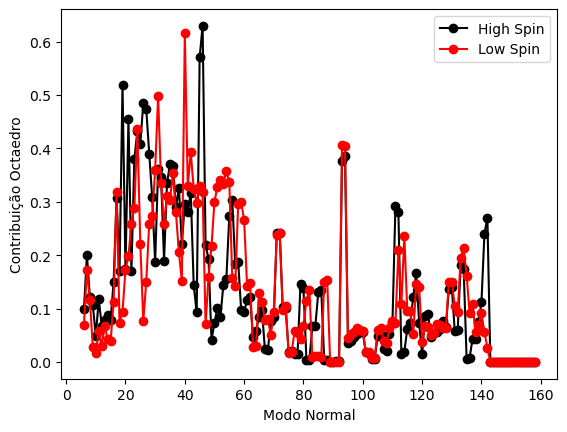

In [27]:
plt.plot(hs['index'],hs['array'],marker='o',label='High Spin',color='black')
plt.plot(ls['index'],ls['array'],marker='o',label='Low Spin',color='red')

plt.xlabel('Modo Normal')
plt.ylabel('Contribuição Octaedro')
plt.legend()
plt.show()

In [29]:
hs.sort_values(by=['array','valor'],ascending=False)[:15]

,index,valor,array
40,46,503.755440,0.629462
39,45,495.166305,0.570897
13,19,125.695132,0.518842
20,26,204.769199,0.484549
21,27,241.390250,0.473349
15,21,144.435391,0.454171
18,24,170.835434,0.431847
19,25,180.125616,0.408547
22,28,248.508294,0.389942
88,94,1031.867542,0.385721


In [31]:
ls.sort_values(by=['array','valor'],ascending=False)[:25]

,index,valor,array,modos
34,40,442.702541,0.615414,442.702541
25,31,328.871848,0.497352,328.871848
18,24,217.822650,0.436885,217.822650
87,93,1043.598043,0.406211,1043.598043
88,94,1046.776066,0.404808,1046.776066
36,42,476.550760,0.392718,476.550760
24,30,313.779893,0.359218,313.779893
48,54,591.609867,0.357008,591.609867
30,36,390.471985,0.354482,390.471985
46,52,585.989826,0.340163,585.989826


# Produto interno entre modos normais LS e HS.

In [34]:
lista_array_ini = []
lista_array_fin = []

for i in range(0,159):
    iesimo_hs_nm = normal_modes_hs[str(i)]
    for j in range(0,159):
        jesimo_ls_nm = normal_modes_ls[str(j)]
        prod_intern = (iesimo_hs_nm*jesimo_ls_nm).sum()
        lista_array_ini.append(prod_intern)
    lista_array_fin.append(lista_array_ini)
    lista_array_ini = []    

In [35]:
prod_intern = pd.DataFrame(lista_array_fin)

In [39]:
valores_modos_hs = pd.read_csv('ls/v2/freq_modos.txt',header=None,sep='\s+')[1]
valores_modos_ls = pd.read_csv('hs/freq_modos.txt',header=None,sep='\s+')[1]

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\3629525896.py:1: SyntaxWarning: invalid escape sequence '\s'
  valores_modos_hs = pd.read_csv('ls/v2/freq_modos.txt',header=None,sep='\s+')[1]
C:\Users\55219\AppData\Local\Temp\ipykernel_26464\3629525896.py:2: SyntaxWarning: invalid escape sequence '\s'
  valores_modos_ls = pd.read_csv('hs/freq_modos.txt',header=None,sep='\s+')[1]


In [44]:
import matplotlib.pyplot as plt
import mplcursors

mat = prod_intern.values
nrows, ncols = mat.shape

fig, ax = plt.subplots(figsize=(15, 15))

img = ax.imshow(mat, interpolation='nearest', origin='upper')
plt.colorbar(img, label='Intensidade')

ax.set_title('Mapa de Calor do Produto Interno')
ax.set_xlabel('Modo Normal LS')
ax.set_ylabel('Modo Normal HS')

cursor = mplcursors.cursor(img, hover=True)
@cursor.connect("add")
@cursor.connect("add")
def on_add(sel):
    # sel.target -> (x, y) onde x = coluna (LS), y = linha (HS)
    x = int(round(sel.target[0]))  # coluna → LS
    y = int(round(sel.target[1]))  # linha  → HS

    if 0 <= x < ncols and 0 <= y < nrows:
        valor_mapa = mat[y, x]  # mais direto que prod_intern.iat[y, x]

        # usar .values para garantir acesso posicional sem rótulos
        valor_hs = np.asarray(valores_modos_hs).ravel()[x]
        valor_ls = np.asarray(valores_modos_ls).ravel()[y]

        sel.annotation.set_text(
            f"HS_freq = {valor_ls:.2f}  (y={y})\n"
            f"LS_freq = {valor_hs:.2f}  (x={x})\n"
            f"Overlap = {valor_mapa:.4e}"
        )


# Produto interno entre modos normais LS e HS só do octaedro

In [58]:
normal_modes_hs_oct = normal_modes_hs.loc[['O1','O2','N3','N4','N5','N6','Fe1']]
normal_modes_ls_oct = normal_modes_ls.loc[['O1','O2','N3','N4','N5','N6','Fe1']]

lista_array_ini = []
lista_array_fin = []

for i in range(0,159):
    iesimo_hs_nm = normal_modes_hs_oct[str(i)]
    for j in range(0,159):
        jesimo_ls_nm = normal_modes_ls_oct[str(j)]
        prod_intern = (iesimo_hs_nm*jesimo_ls_nm).sum()
        lista_array_ini.append(prod_intern)
    lista_array_fin.append(lista_array_ini)
    lista_array_ini = []   

prod_intern = pd.DataFrame(lista_array_fin)

In [60]:
import matplotlib.pyplot as plt
import mplcursors

mat = prod_intern.values
nrows, ncols = mat.shape

fig, ax = plt.subplots(figsize=(15, 15))

img = ax.imshow(mat, interpolation='nearest', origin='upper')
plt.colorbar(img, label='Intensidade')

ax.set_title('Mapa de Calor do Produto Interno')
ax.set_xlabel('Modo Normal LS')
ax.set_ylabel('Modo Normal HS')

cursor = mplcursors.cursor(img, hover=True)
@cursor.connect("add")
@cursor.connect("add")
def on_add(sel):
    # sel.target -> (x, y) onde x = coluna (LS), y = linha (HS)
    x = int(round(sel.target[0]))  # coluna → LS
    y = int(round(sel.target[1]))  # linha  → HS

    if 0 <= x < ncols and 0 <= y < nrows:
        valor_mapa = mat[y, x]  # mais direto que prod_intern.iat[y, x]

        # usar .values para garantir acesso posicional sem rótulos
        valor_hs = np.asarray(valores_modos_hs).ravel()[x]
        valor_ls = np.asarray(valores_modos_ls).ravel()[y]

        sel.annotation.set_text(
            f"HS_freq = {valor_ls:.2f}  (y={y})\n"
            f"LS_freq = {valor_hs:.2f}  (x={x})\n"
            f"Overlap = {valor_mapa:.4e}"
        )


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplcursors
import matplotlib.colors as colors

# --- Cálculo do produto interno ---
normal_modes_hs_oct = normal_modes_hs.loc[['O1','O2','N3','N4','N5','N6','Fe1']]
normal_modes_ls_oct = normal_modes_ls.loc[['O1','O2','N3','N4','N5','N6','Fe1']]

lista_array_fin = []

for i in range(0,159):
    iesimo_hs_nm = normal_modes_hs_oct[str(i)]
    lista_array_ini = []
    for j in range(0,159):
        jesimo_ls_nm = normal_modes_ls_oct[str(j)]
        prod_intern = (iesimo_hs_nm * jesimo_ls_nm).sum()
        lista_array_ini.append(prod_intern)
    lista_array_fin.append(lista_array_ini)

prod_intern = pd.DataFrame(lista_array_fin)

# --- Preparar matriz e aplicar threshold ---
mat = prod_intern.values
threshold = 1e-2

mat_plot = mat.copy()
mat_plot[np.abs(mat_plot) < threshold] = 0.0  # valores pequenos -> 0

nrows, ncols = mat_plot.shape

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 15))

# Criar colormap com cor branca para valores abaixo de vmin
cmap = plt.cm.viridis.copy()
cmap.set_under('white')  # tudo que for < vmin aparece branco

img = ax.imshow(
    mat_plot,
    interpolation='nearest',
    origin='upper',
    cmap=cmap,
    vmin=1e-12   # necessário para ativar o "under"
)

plt.colorbar(img, label='Intensidade')

ax.set_title('Mapa de Calor do Produto Interno')
ax.set_xlabel('Modo Normal LS')
ax.set_ylabel('Modo Normal HS')

# --- Hover com frequências ---
cursor = mplcursors.cursor(img, hover=True)

@cursor.connect("add")
def on_add(sel):
    x = int(round(sel.target[0]))  # coluna → LS
    y = int(round(sel.target[1]))  # linha  → HS

    if 0 <= x < ncols and 0 <= y < nrows:
        valor_mapa = mat[y, x]  # usar a matriz original (não a filtrada)

        valor_hs = np.asarray(valores_modos_hs).ravel()[x]
        valor_ls = np.asarray(valores_modos_ls).ravel()[y]

        sel.annotation.set_text(
            f"HS_freq = {valor_ls:.2f}  (y={y})\n"
            f"LS_freq = {valor_hs:.2f}  (x={x})\n"
            f"Overlap = {valor_mapa:.4e}"
        )
